Jumlah data berlabel dan file valid: 21587
gender
male_masculine     13983
female_feminine     7604
Name: count, dtype: int64


c:\Users\Asus\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Jumlah data berhasil diekstraksi: 21587
Dimensi fitur: 24
male_masculine     13983
female_feminine     7604
Name: count, dtype: int64


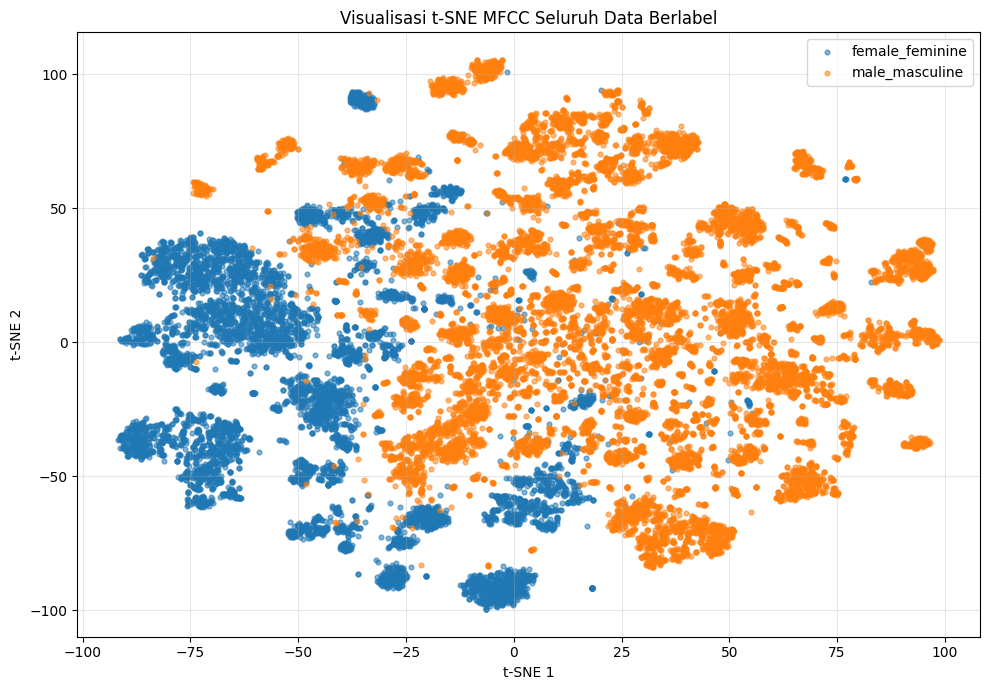

In [1]:
# ============================================================
# EDA: t-SNE MFCC SELURUH DATA BERLABEL
# ============================================================

import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. Parameter dan load dataset
# ------------------------------------------------------------

metadata_path = "validated.tsv"
audio_folder = "clips"
TARGET_SR = 16000
PRE_EMPHASIS = 0.97
N_MFCC = 24
N_FFT = 512
WIN_LENGTH = 400
HOP_LENGTH = 160

# EDA ini menggunakan seluruh data dengan label gender yang tersedia.
df = pd.read_csv(metadata_path, sep="\t")
df_labeled = df[
    df["gender"].isin(["male_masculine", "female_feminine"])
].copy()

# Hanya file audio yang benar-benar tersedia yang diproses.
df_labeled["audio_path"] = df_labeled["path"].map(
    lambda path: os.path.join(audio_folder, path)
)
df_labeled = df_labeled[
    df_labeled["audio_path"].map(os.path.exists)
].reset_index(drop=True)

print("Jumlah data berlabel dan file valid:", len(df_labeled))
print(df_labeled["gender"].value_counts())

# ------------------------------------------------------------
# 2. Fungsi ekstraksi MFCC
# ------------------------------------------------------------

def extract_mfcc_tsne(file_path):
    try:
        y, sr = librosa.load(
            file_path,
            sr=TARGET_SR,
            mono=True
        )

        if y.size == 0:
            return None

        y = np.append(
            y[0],
            y[1:] - PRE_EMPHASIS * y[:-1]
        )

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            win_length=WIN_LENGTH,
            hop_length=HOP_LENGTH
        )

        return np.mean(mfcc, axis=1)

    except Exception as error:
        print(f"Error pada {file_path}: {error}")
        return None

# ------------------------------------------------------------
# 3. Ekstraksi fitur seluruh data
# ------------------------------------------------------------

features = []
labels = []
paths = []

for _, row in df_labeled.iterrows():
    feature = extract_mfcc_tsne(row["audio_path"])

    if feature is not None:
        features.append(feature)
        labels.append(row["gender"])
        paths.append(row["path"])

X = np.asarray(features)
labels = np.asarray(labels)

print("\nJumlah data berhasil diekstraksi:", X.shape[0])
print("Dimensi fitur:", X.shape[1])
print(pd.Series(labels).value_counts())

# ------------------------------------------------------------
# 4. Standardisasi fitur
# ------------------------------------------------------------

X_scaled = StandardScaler().fit_transform(X)

# ------------------------------------------------------------
# 5. Reduksi dimensi dengan t-SNE menjadi 2D
# ------------------------------------------------------------

perplexity = min(30, X_scaled.shape[0] - 1)
tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init="pca",
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

# ------------------------------------------------------------
# 6. Visualisasi
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

colors = {
    "female_feminine": "tab:blue",
    "male_masculine": "tab:orange"
}

for label in ["female_feminine", "male_masculine"]:
    index = labels == label
    plt.scatter(
        X_tsne[index, 0],
        X_tsne[index, 1],
        s=12,
        alpha=0.55,
        c=colors[label],
        label=label
    )

plt.title("Visualisasi t-SNE MFCC Seluruh Data Berlabel")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()